# Clustering with Scikit-learn in Python
**A tutorial by Thomas Jurczyk, CERES (Bochum)**

This notebook includes the code used in my clustering tutorial for the [Programming Historian](https://programminghistorian.org/). Please note that you need to save the datasets `DNP_ancient_authors.csv` and `RELIGION_abstracts.csv` in the a folder called `data`. The datasets are available in my [GitHub repository](https://github.com/thomjur/clustering_with_sklearn_in_Python_PH).

If you have any questions or comments, please contact me via [email](mailto:thomas.jurczyk-q88@rub.de).
<br>
<br>
---

# DNP Ancient Authors Data

## 1. Loading the Datasets & Exploratory Data Analysis
In the first step, we will load the `DNP_ancient_authors.csv` dataset into our program and look at some overview statistics.

In [5]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# load the authors dataset that has been stored as a .csv files in a folder called "data" in the same directory as the Jupyter Notebook
df_authors = pd.read_csv("data/DNP_ancient_authors.csv", index_col="authors").drop(columns=["Unnamed: 0"])

In the next step, we print out the first five rows and look at some information and overview statistcs about each dataset using pandas' `info()` and `describe()` methods.

In [6]:
df_authors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, Achilles Tatius of Alexandria to Zosimus
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   word_count           238 non-null    int64
 1   modern_translations  238 non-null    int64
 2   known_works          238 non-null    int64
 3   manuscripts          238 non-null    int64
 4   early_editions       238 non-null    int64
 5   early_translations   238 non-null    int64
 6   modern_editions      238 non-null    int64
 7   commentaries         238 non-null    int64
dtypes: int64(8)
memory usage: 16.7+ KB


In [7]:
df_authors.head(5)

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
authors,,,,,,,,
Achilles Tatius of Alexandria,383,5,1,2,3,9,2,1
Aelianus Tacticus,350,1,1,0,3,6,1,0
"Aelianus, Claudius (Aelian)",746,8,3,6,10,8,7,0
Aelius Aristides (Publius Aelius Aristides),2180,26,22,7,11,6,15,1
Aeneas Tacticus,304,5,1,1,1,2,6,0


In [8]:
df_authors.describe()

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,904.441176,12.970588,4.735294,4.512605,5.823529,4.794118,10.399160,3.815126
std,804.388666,16.553047,6.784297,4.637702,4.250881,6.681706,11.652326,7.013509
min,99.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,448.750000,4.250000,1.000000,1.000000,3.000000,0.000000,4.000000,0.000000
50%,704.000000,9.000000,2.000000,3.000000,5.000000,2.500000,7.000000,1.000000
75%,1151.500000,15.750000,6.000000,6.000000,8.000000,8.000000,14.000000,4.000000
max,9406.000000,178.000000,65.000000,34.000000,28.000000,39.000000,115.000000,43.000000


As we can see when using `describe()` on the `df_authors` dataset, we have an overall huge standard deviation in almost every column and a huge difference between the 75% percentil value and the maxim value. This indicates that we might have some serious outliers in our dataset, and it might make sense to get rid of them before we continue with our analysis. Therefore, we only keep those data points in our dataframe with a `word_count` within the 95% percentil range.

In [9]:
ninety_quantile = df_authors["word_count"].quantile(0.9)

In [10]:
df_authors = df_authors[df_authors["word_count"] <= ninety_quantile]

In [11]:
df_authors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, Achilles Tatius of Alexandria to Zosimus
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   word_count           214 non-null    int64
 1   modern_translations  214 non-null    int64
 2   known_works          214 non-null    int64
 3   manuscripts          214 non-null    int64
 4   early_editions       214 non-null    int64
 5   early_translations   214 non-null    int64
 6   modern_editions      214 non-null    int64
 7   commentaries         214 non-null    int64
dtypes: int64(8)
memory usage: 15.0+ KB


In [12]:
df_authors.describe()

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,725.420561,10.247664,3.588785,3.864486,5.219626,3.803738,8.462617,2.915888
std,391.536699,9.036669,4.153065,3.934362,3.437352,4.896946,6.905533,5.421435
min,99.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,427.500000,4.000000,1.000000,1.000000,3.000000,0.000000,4.000000,0.000000
50%,651.000000,8.000000,2.000000,3.000000,5.000000,2.000000,6.000000,1.000000
75%,951.000000,14.000000,5.000000,6.000000,7.000000,6.000000,12.000000,3.000000
max,1772.000000,67.000000,24.000000,34.000000,17.000000,30.000000,35.000000,42.000000


## 2. Analyzing the DNP Ancient Authors Dataset
We start our analysis by clustering the `DNP_ancient_authors.csv` dataset. Before we start with the actual clustering process, we first import all the necessary library and write a couple of functions that will help us to plot our results during the analysis. We will also use these functions and imports in the second part of our analysis.

Before continuing with the following part, you need to install `yellowbrick` first if you haven't done so already. You can either do this via

`pip install yellowbrick`

or

`conda install yellowbrick`

when using the Anaconda distribution.

In [13]:
from sklearn.preprocessing import StandardScaler as SS # z-score standardization
from sklearn.cluster import KMeans, DBSCAN # clustering algorithms
from sklearn.decomposition import PCA # dimensionality reduction
from sklearn.metrics import silhouette_score # used as a metric to evaluate the cohesion in a cluster
from sklearn.neighbors import NearestNeighbors # for selecting the optimal eps value when using DBSCAN
import numpy as np

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import SilhouetteVisualizer

In [14]:
def silhouettePlot(range_, data):
    '''
    we will use this function to plot a silhouette plot that helps us to evaluate the cohesion in clusters (k-means only)
    '''
    half_length = int(len(range_)/2)
    range_list = list(range_)
    fig, ax = plt.subplots(half_length, 2, figsize=(15,8))
    for _ in range_:
        kmeans = KMeans(n_clusters=_, random_state=42)
        q, mod = divmod(_ - range_list[0], 2)
        sv = SilhouetteVisualizer(kmeans, colors="yellowbrick", ax=ax[q][mod])
        ax[q][mod].set_title("Silhouette Plot with n={} Cluster".format(_))
        sv.fit(data)
    fig.tight_layout()
    fig.show()
    fig.savefig("silhouette_plot.png")

In [15]:
def elbowPlot(range_, data, figsize=(10,10)):
    '''
    the elbow plot function helps to figure out the right amount of clusters for a dataset
    '''
    inertia_list = []
    for n in range_:
        kmeans = KMeans(n_clusters=n, random_state=42)
        kmeans.fit(data)
        inertia_list.append(kmeans.inertia_)

    # plotting
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    sns.lineplot(y=inertia_list, x=range_, ax=ax)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Inertia")
    ax.set_xticks(list(range_))
    fig.show()
    fig.savefig("elbow_plot.png")

In [16]:
def findOptimalEps(n_neighbors, data):
    '''
    function to find optimal eps distance when using DBSCAN; based on this article: https://towardsdatascience.com/machine-learning-clustering-dbscan-determine-the-optimal-value-for-epsilon-eps-python-example-3100091cfbc
    '''
    neigh = NearestNeighbors(n_neighbors=n_neighbors)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.savefig("eps_plot.png")

In [17]:
def progressiveFeatureSelection(df, n_clusters=3, max_features=4,):
    '''
    very basic implementation of an algorithm for feature selection (unsupervised clustering); taken from this post: https://datascience.stackexchange.com/questions/67040/how-to-do-feature-selection-for-clustering-and-implement-it-in-python
    '''
    feature_list = list(df.columns)
    selected_features = list()
    # select starting feature
    initial_feature = ""
    high_score = 0
    for feature in feature_list:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        data_ = df[feature]
        labels = kmeans.fit_predict(data_.to_frame())
        score_ = silhouette_score(data_.to_frame(), labels)
        print("Proposed new feature {} with score {}". format(feature, score_))
        if score_ >= high_score:
            initial_feature = feature
            high_score = score_
    print("The initial feature is {} with a silhouette score of {}.".format(initial_feature, high_score))
    feature_list.remove(initial_feature)
    selected_features.append(initial_feature)
    for _ in range(max_features-1):
        high_score = 0
        selected_feature = ""
        print("Starting selection {}...".format(_))
        for feature in feature_list:
            selection_ = selected_features.copy()
            selection_.append(feature)
            kmeans = KMeans(n_clusters=n_clusters, random_state=42)
            data_ = df[selection_]
            labels = kmeans.fit_predict(data_)
            score_ = silhouette_score(data_, labels)
            print("Proposed new feature {} with score {}". format(feature, score_))
            if score_ > high_score:
                selected_feature = feature
                high_score = score_
        selected_features.append(selected_feature)
        feature_list.remove(selected_feature)
        print("Selected new feature {} with score {}". format(selected_feature, high_score))
    return selected_features

## 3. Standardizing the DNP Ancient Authors Dataset
Next, we initialize scikit-learn's `StandardScaler()` to standardize our data.

In [18]:
scaler = SS()

In [19]:
DNP_authors_standardized = scaler.fit_transform(df_authors)

In [20]:
DNP_authors_standardized

array([[-0.87660601, -0.58206932, -0.62480479, ...,  1.06361092,
        -0.93805493, -0.35421989],
       [-0.96108691, -1.02574817, -0.62480479, ...,  0.44954778,
        -1.08320588, -0.5391054 ],
       [ 0.05268393, -0.24931019, -0.14210362, ...,  0.8589232 ,
        -0.21230021, -0.5391054 ],
       ...,
       [-0.04459711,  1.41448547,  0.34059756, ..., -0.7785785 ,
         0.8037564 ,  0.01555112],
       [-1.0250876 ,  0.41620807, -0.62480479, ..., -0.7785785 ,
        -0.5026021 , -0.5391054 ],
       [-0.9406067 , -0.13839048, -0.62480479, ..., -0.7785785 ,
        -0.93805493, -0.35421989]])

In [21]:
df_authors_standardized = pd.DataFrame(DNP_authors_standardized, columns=["word_count_standardized", "modern_translations_standardized", "known_works_standardized", "manuscripts_standardized", "early_editions_standardized", "early_translations_standardized", "modern_editions_standardized", "commentaries_standardized"])
df_authors_standardized = df_authors_standardized.set_index(df_authors.index)

## 4. Feature Selection
This next section is a little fuzzy. Selecting features in an unsupervised learning context is difficult. I have decided to implement a rather "simple" approach (see the function `progressiveFeatureSelection`). This attempt is based on [this algorithm presented on stackexchange](https://datascience.stackexchange.com/questions/67040/how-to-do-feature-selection-for-clustering-and-implement-it-in-python). Of course, there are more elaborate attempts to select features in an unsupervised learning context, such as presented in [this article](https://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.295.8115&rep=rep1&type=pdf). However, the method implemented here turned out to be quite successful in the context of the datasets used in this tutorial.

For the sake of simplicity and since we only have ten features in the `DNP_ancient_authors.csv` dataset, we are looking for the ideal three features to cluster our data.

In [22]:
selected_features = progressiveFeatureSelection(df_authors_standardized, max_features=3, n_clusters=3)

Proposed new feature word_count_standardized with score 0.5815823896749474
Proposed new feature modern_translations_standardized with score 0.5917853484820189
Proposed new feature known_works_standardized with score 0.7606223362466435
Proposed new feature manuscripts_standardized with score 0.6126173050657406
Proposed new feature early_editions_standardized with score 0.5572659274387843
Proposed new feature early_translations_standardized with score 0.7025924996773049
Proposed new feature modern_editions_standardized with score 0.6105799708876277
Proposed new feature commentaries_standardized with score 0.7640761496282473
The initial feature is commentaries_standardized with a silhouette score of 0.7640761496282473.
Starting selection 0...
Proposed new feature word_count_standardized with score 0.49823573315720454
Proposed new feature modern_translations_standardized with score 0.4794041704969361
Proposed new feature known_works_standardized with score 0.6073438290962909
Proposed new f

In [23]:
selected_features

['commentaries_standardized',
 'known_works_standardized',
 'modern_editions_standardized']

It turns out that the features `known_works_standardized`, `commentaries_standardized`, and `modern_editions_standardized` might be worth using when trying to cluster our data. We are creating a new dataframe with only these three features.

In [24]:
df_standardized_sliced = df_authors_standardized[selected_features]

In [25]:
df_standardized_sliced

,commentaries_standardized,known_works_standardized,modern_editions_standardized
authors,,,
Achilles Tatius of Alexandria,-0.354220,-0.624805,-0.938055
Aelianus Tacticus,-0.539105,-0.624805,-1.083206
"Aelianus, Claudius (Aelian)",-0.539105,-0.142104,-0.212300
Aeneas Tacticus,-0.539105,-0.624805,-0.357451
Aeschylus of Athens,3.158605,0.823299,0.948907
...,...,...,...
"Venantius Fortunatus, Honorius Clementianus",-0.539105,0.099247,-0.792904
Vergiliana Appendix,1.124864,1.306000,0.803756
Xenophon of Athens,0.015551,0.340598,0.803756


## 5. Figuring Out the Right Amount of Clusters

We will now apply the elbow method and then use silhouette plots to get an impression of how many clusters we should choose to analyse our dataset. We will check for two to ten clusters. Note, however, that the feature selection was also done with a pre-defined k-means algorithm using n=3 clusters. Thus, our three selected features might already have a tendency towards this amount of clusters, since they turned out to be the best choice under the parametric circumstances of n=3 cluster.

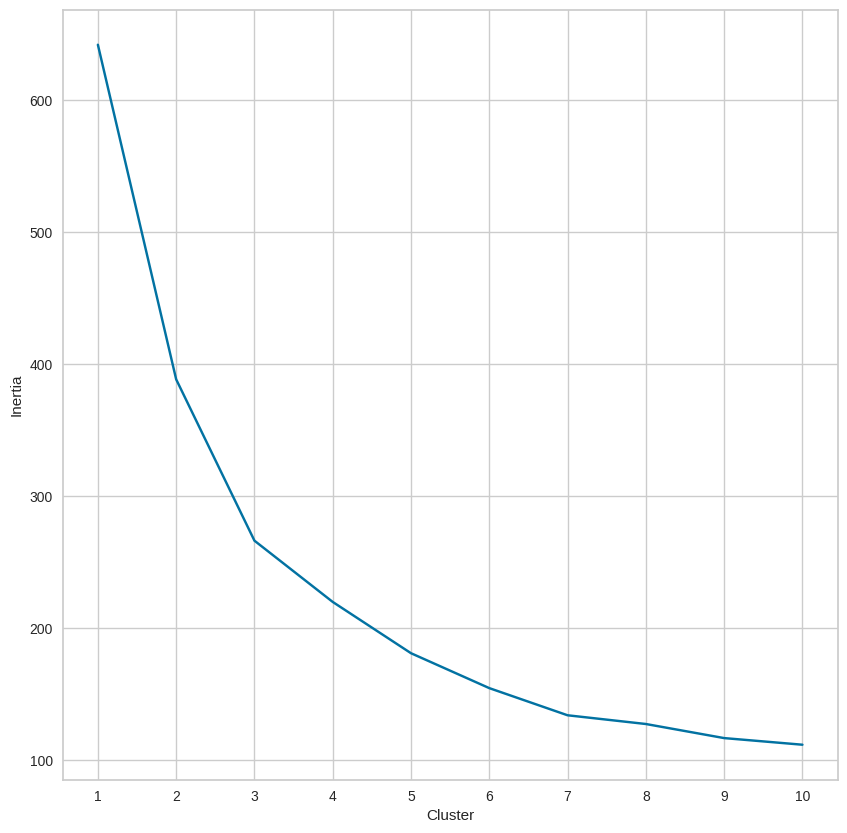

In [26]:
elbowPlot(range(1,11), df_standardized_sliced)

Looking at the elbow plot indeed shows us that an "elbow" at n=3 as well as n=5 clusters. However, it's still pretty difficult to decide whether to use three, four, five or even six clusters. Therefore, we should also look at the silhouette plots.

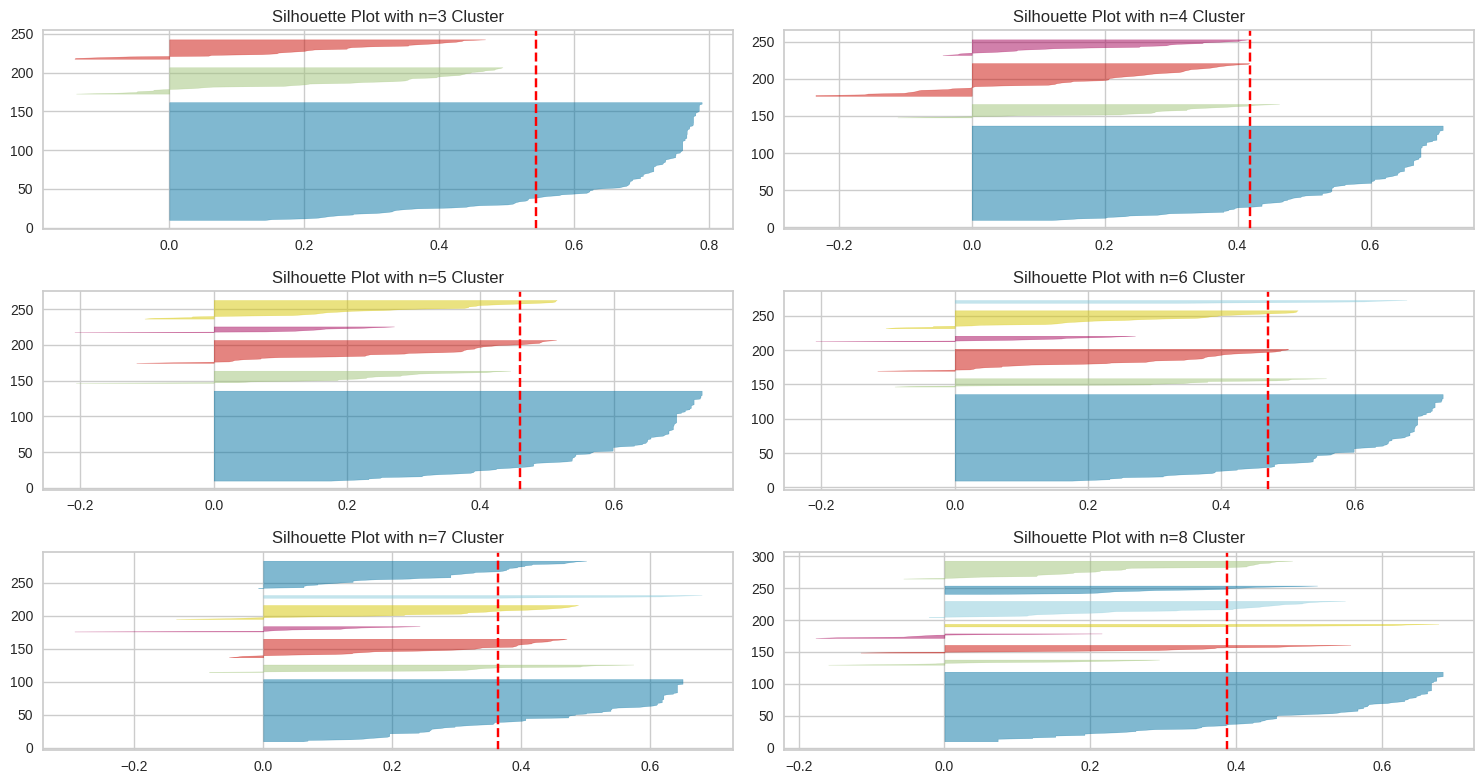

In [28]:
silhouettePlot(range(3,9), df_standardized_sliced)

Looking at the silhouette scores underlines our previous intuition that a selection of n=3 or n=5 seems to be the right choice of clusters. The silhouette plot with n=3 clusters in particular has a relatively high average silhouette score. Yet, since the two other clusters are far below the average silhouette score for n=3 clusters, we decide to analyze the dataset with k-means using n=5 clusters. However, the different sizes of the “knives” and their sharp form in both n=3 and n=5 clusters indicate a single dominant cluster and a couple of rather small and less cohesive clusters.

## 6. n=5 K-Means Analysis of the DNP Ancient Authors Dataset
Let us now train an k-means instance with n=5 clusters and plot the results using *seaborn*. Since we are focusing the plotting part in this tutorial on two dimensional plots, we wil us `PCA()` (Principal Component Analysis) to reduce the dimensionality to two dimensions for plotting reasons only.

In [29]:
kmeans = KMeans(n_clusters=5, random_state=42)

In [30]:
cluster_labels = kmeans.fit_predict(df_standardized_sliced)

In [31]:
df_standardized_sliced["clusters"] = cluster_labels

/tmp/ipykernel_25823/2530133707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_standardized_sliced["clusters"] = cluster_labels


In [32]:
# using PCA to reduce the dimenionality to two dimenions (to be able to plot the data with *seaborn*)
pca = PCA(n_components=2, whiten=False, random_state=42)
authors_standardized_pca = pca.fit_transform(df_standardized_sliced)
df_authors_standardized_pca = pd.DataFrame(data=authors_standardized_pca, columns=["pc_1", "pc_2"])
df_authors_standardized_pca["clusters"] = cluster_labels

In [33]:
df_authors_standardized_pca

,pc_1,pc_2,clusters
0,-1.474561,-0.479859,0
1,-1.610215,-0.476877,0
2,-1.139692,0.283942,0
3,-1.320231,-0.148965,0
4,3.445289,-0.672530,3
...,...,...,...
209,-1.310407,0.205276,0
210,1.881348,0.664918,2
211,1.170318,0.341652,2
212,-1.378228,-0.214547,0


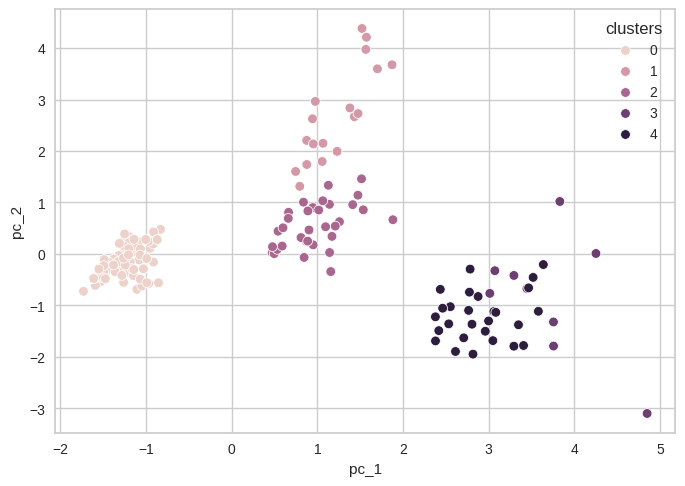

In [34]:
sns_plot = sns.scatterplot(x="pc_1", y="pc_2", hue="clusters", data=df_authors_standardized_pca)

In [35]:
sns_plot.get_figure().savefig("dnp_ancient_authors_kmeans_plot_final_n=5.png")

This looks interesting! Even though the data is not perfectly clustered (which is something that we could already see during the evaluation of the silhouette plot), we can clearly separate at least one to two clusters. However, the two smaller ones still include quite a few outliers, which is a common problem of k-means.

Let us now look at the entries in the three clusters and see if this actually delivered any valuable insights into our data.

In [36]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 0].index].describe() # authors with very few known works and few modern editions/commentaries

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000
mean,513.755906,6.133858,1.480315,2.748031,4.133858,2.685039,4.582677,0.834646
std,258.567443,5.192122,0.907206,2.922188,3.097265,3.642127,2.953182,1.440700
min,99.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,325.000000,2.000000,1.000000,1.000000,2.000000,0.000000,2.000000,0.000000
50%,472.000000,5.000000,1.000000,2.000000,4.000000,0.000000,4.000000,0.000000
75%,654.000000,9.000000,2.000000,4.000000,6.000000,5.000000,6.500000,1.000000
max,1620.000000,37.000000,5.000000,15.000000,17.000000,17.000000,14.000000,6.000000


In [37]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 1].index].describe() # authors many known works and many modern editions, but almost no commentaries

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,1362.388889,21.500000,12.388889,6.388889,8.222222,2.611111,23.000000,1.111111
std,186.863001,9.702941,5.791869,4.948427,3.299832,3.012501,5.830952,1.278275
min,1101.000000,8.000000,3.000000,0.000000,4.000000,0.000000,14.000000,0.000000
25%,1227.500000,14.500000,9.250000,4.000000,6.000000,0.250000,19.000000,0.000000
50%,1363.500000,19.000000,11.500000,6.000000,7.000000,2.000000,21.000000,1.000000
75%,1407.000000,27.250000,15.500000,9.250000,11.000000,3.000000,27.000000,1.000000
max,1772.000000,48.000000,24.000000,16.000000,14.000000,10.000000,35.000000,4.000000


In [38]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 1].index]

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
authors,,,,,,,,
Ambrosius,1221,20,14,6,6,3,31,0
"Boethius, Anicius Manlius Severinus",1359,20,9,11,7,2,24,1
Cyprianus Thascius Caecili(an)us,1368,17,24,6,6,3,16,1
Dion Cocceianus of Prusa (Dio Chrysostom),1152,18,17,6,5,3,14,1
Dionysius of Halicarnassus,1320,13,10,7,14,10,17,3
Epicurus,1412,48,6,4,4,0,30,1
"Hieronymus, Sophronius Eusebius (Jerome)",1772,18,14,16,14,2,21,4
"Iulianus, Flavius Claudius (Julian the Apostate)",1392,25,13,4,8,4,19,0
"Iuvenalis, Decimus Iunius (Juvenal)",1247,12,16,4,11,10,18,4


In [39]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 2].index].describe() # authors with few known works, but a lot of commentaries and relatively many modern editions

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,33.000000,33.000000,33.000000,33.000000,33.00000,33.000000,33.000000,33.000000
mean,889.363636,11.303030,7.303030,5.333333,5.69697,4.000000,9.575758,1.969697
std,294.378033,5.801319,2.068889,5.850570,3.63563,5.567764,4.161057,2.493552
min,534.000000,2.000000,3.000000,0.000000,0.00000,0.000000,4.000000,0.000000
25%,708.000000,7.000000,6.000000,2.000000,3.00000,0.000000,6.000000,0.000000
50%,805.000000,11.000000,8.000000,5.000000,5.00000,1.000000,10.000000,1.000000
75%,954.000000,14.000000,9.000000,6.000000,8.00000,6.000000,13.000000,3.000000
max,1722.000000,30.000000,11.000000,34.000000,14.00000,20.000000,16.000000,9.000000


In [40]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 2].index]

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
authors,,,,,,,,
Alexander Romance (Pseudo-Callisthenes),1722,19,8,34,0,19,11,0
Antiphon of Rhamnus,954,7,6,2,6,0,11,1
Apostolic Fathers (Patres apostolici),779,14,9,0,3,0,15,3
Appianus,894,14,10,2,5,13,11,6
Archimedes of Syracuse,742,6,10,7,3,4,4,0
Arrianus of Nicomedia (Lucius Flavius Arrianus; Arrian),1215,21,8,5,14,20,13,1
"Cassiodorus, Flavius Magnus Aurelius",730,7,8,10,8,4,11,4
"Cato, Marcus Porcius (Cato the Elder)",623,8,3,3,5,0,15,1
"Celsus, Aulus Cornelius",888,14,8,5,4,4,15,3


In [41]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 3].index].describe() # authors with few commentaries and an average number of known works and modern editions

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,1420.888889,29.888889,6.444444,5.777778,6.888889,10.333333,16.777778,22.333333
std,243.859819,15.679959,5.479761,3.527668,2.027588,10.037430,7.276293,7.810250
min,1018.000000,17.000000,1.000000,2.000000,5.000000,0.000000,7.000000,16.000000
25%,1292.000000,18.000000,2.000000,4.000000,5.000000,0.000000,14.000000,18.000000
50%,1485.000000,29.000000,5.000000,5.000000,6.000000,14.000000,15.000000,20.000000
75%,1504.000000,31.000000,8.000000,6.000000,8.000000,15.000000,20.000000,22.000000
max,1758.000000,67.000000,18.000000,12.000000,10.000000,30.000000,31.000000,42.000000


In [42]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 3].index]

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
authors,,,,,,,,
Aeschylus of Athens,1758,31,7,5,10,14,15,20
Aristophanes of Athens,1108,18,11,2,6,30,7,18
"Lucanus, Marcus Annaeus",1018,17,1,11,8,15,20,25
Plato,1681,31,18,5,5,0,10,20
Plutarchus of Chaeronea (Plutarch),1485,37,2,2,6,0,15,42
"Propertius, Sextus",1443,22,1,5,5,5,24,22
"Sallustius Crispus, Gaius (Sallust)",1292,17,5,12,7,15,15,16
Sophocles,1499,67,8,4,5,0,14,18
"Tacitus, (Publius?) Cornelius",1504,29,5,6,10,14,31,20


In [43]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 4].index].describe() # authors with a very high amount of commentaries and an average amount of known works and modern editions

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,864.185185,14.259259,2.148148,5.000000,7.185185,7.444444,12.888889,8.592593
std,250.676015,6.143117,1.747607,2.759599,2.896112,4.627122,4.782447,3.835655
min,436.000000,5.000000,1.000000,2.000000,2.000000,0.000000,2.000000,1.000000
25%,656.000000,10.000000,1.000000,3.000000,5.000000,4.500000,10.000000,6.000000
50%,872.000000,14.000000,1.000000,4.000000,7.000000,8.000000,13.000000,9.000000
75%,1039.000000,17.000000,3.000000,7.000000,10.000000,9.500000,15.500000,11.000000
max,1383.000000,30.000000,7.000000,11.000000,12.000000,19.000000,22.000000,15.000000


In [44]:
df_authors.iloc[df_authors_standardized_pca[df_authors_standardized_pca["clusters"] == 4].index]

,word_count,modern_translations,known_works,manuscripts,early_editions,early_translations,modern_editions,commentaries
authors,,,,,,,,
Ap(p)uleius of Madaura,872,5,6,3,4,6,16,11
"Caesar, Caius Iulius",948,30,2,2,10,9,22,9
Callimachus of Cyrene,652,11,5,4,2,0,10,8
"Catullus, Valerius",1197,19,1,6,10,6,21,12
"Curtius Rufus, Quintus",636,14,1,5,5,9,10,9
Diogenes Laertius,1225,28,1,9,12,6,22,1
Homeric Hymns,825,14,1,7,10,6,9,6
Iosephus Flavius (Flavius Josephus),952,22,4,3,4,15,12,6
"Livius, Titus (Livy)",1383,15,1,9,7,14,14,15


This provided us with quite some interesting results. Note, however, that many of the known authors are missing due to our initial cut off of 10% of the data. In an actual research article, this might be a bad idea, however, it facilitated our clustering process.

-------------------

# *Religion* Abstracts Data
The second part of this tutorial is going to deal with textual data, namely all abstracts scraped from the [*Religion* (journal)](https://www.tandfonline.com/toc/rrel20/current) website. We will try to cluster the abstracts based on their word features in the form of **TF-IDF** vectors (which is short for "**T**ext **F**requency - **I**nverted **D**ocument **F**requency").

## 1. Loading the Dataset & Exploratory Data Analysis
Similar to the analysis of the `DNP_ancient_authors.csv` dataset, we will first load the `RELIGION_abstracts.csv` into our program and look at some descriptive statistics.

In [49]:
df_abstracts = pd.read_csv("data/RELIGION_abstracts_lemmatized.csv").drop(columns="Unnamed: 0")

FileNotFoundError: [Errno 2] No such file or directory: 'data/RELIGION_abstracts_lemmatized.csv'

In [ ]:
df_abstracts.info()

In [ ]:
df_abstracts.describe()

## 2. TF-IDF Vectorization

In order to process the textual data with clustering algorithms, we need to convert the texts to vectors. For this purpose, we are using the scikit-learn implementation of **TF-IDF** vectorization. For a good introduction to how TF-IDF works, see this [great tutorial by Melanie Walsh](https://melaniewalsh.github.io/Intro-Cultural-Analytics/Text-Analysis/TF-IDF-Scikit-Learn.html).

As an optional step, I have implemented a function called `lemmatizeAbstracts()` that lemmatizes the abstracts for us. Since we are not interested in stylistic similiarities between the abstracts, this might help us to reduce the overall amount of features (words) in our dataset. As part of the function, we are also cleaning the text of all punctuation and other noise such as brackets etc. In the following part, we are only working with the lemmatized version of the abstracts. However, if you feel like it, you can also continue using the original texts.

### *Optional Step*: Lemmatization of Abstracts (using *spacy*)

In [ ]:
# lemmatization (optional step)
import spacy
import re
nlp = spacy.load("en_core_web_sm")

def lemmatizeAbstracts(x):
        doc = nlp(x)
        new_text = []
        for token in doc:
            new_text.append(token.lemma_)
        text_string = " ".join(new_text)
        # getting rid of non-word characters
        text_string = re.sub(r"[^\w\s]+", "", text_string)
        text_string = re.sub(r"\s{2,}", " ", text_string)
        return text_string

df_abstracts["abstract_lemma"] = df_abstracts["abstract"].apply(lemmatizeAbstracts)
df_abstracts.to_csv("data/RELIGION_abstracts_lemmatized.csv")

```Python
# lemmatization (optional step)
import spacy
import re
nlp = spacy.load("en_core_web_sm")

def lemmatizeAbstracts(x):
        doc = nlp(x)
        new_text = []
        for token in doc:
            new_text.append(token.lemma_)
        text_string = " ".join(new_text)
        # getting rid of non-word characters
        text_string = re.sub(r"[^\w\s]+", "", text_string)
        text_string = re.sub(r"\s{2,}", " ", text_string)
        return text_string
    
df_abstracts["abstract_lemma"] = df_abstracts["abstract"].apply(lemmatizeAbstracts)
df_abstracts.to_csv("data/RELIGION_abstracts_lemmatized.csv")
```

I recommend saving the new lemmatized version of the dataset so that we do not have to redo the lemmatization each time we restart our notebook.

The first step is to instantiate our TF-IDF model by passing it the argument to ignore stop words, such as "the," "a," etc. The second step is pretty similar to the training of our K-Means instance in the previous part: We are passing the abstracts from our dataset to the vectorizer in order to convert them to machine-readable vectors. For the moment, we are not passing any additional arguments. Finally, we create a new pandas DataFrame object based on the TF-IDF matrix of our textual data.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [47]:
tfidf = TfidfVectorizer(stop_words="english")

In [48]:
df_abstracts_tfidf = tfidf.fit_transform(df_abstracts["abstract_lemma"])

NameError: name 'df_abstracts' is not defined

In [ ]:
df_abstracts_tfidf

Our initial matrix is *huge* and includes over 8,000 words from the overall vocabulary of the 701 abstracts. This is obviously too much, not only from a computational perspective, but also because clustering algorithms such as k-means loose much of their power due to the so-called *curse of dimensionality*. We will thus need to significantly reduce the number of features. To do so, we first create a new instance of the `df_abstracts_tfidf` with reduced maximum features to 250. We also tell the model to only consider words from the vocabulary that appear in at least five different documents but not more than 100 times. We also add the possibility to not only include single words, but bigrams as well (such as "19th century"). Finally, we tell our model to get rid of any potential accents.

Secondly, we are also using the *Principal Component Analysis* (PCA), a technique that is often applied to reduce the dimensionality of datasets.

> PCA allows us to reduce the dimensionality of the original data substantially while retaining most of the salient information. On the PCA-reduced feature set, other machine learning algorithms—downstream in the machine learning pipeline—will have an easier time separating the data points in space (to perform tasks such as anomaly detection and clustering) and will require fewer computational resources. (quote from the online version of Ankur A. Patel: *Hands-On Unsupervised Learning Using Python*, O'Reilly Media 2020)

In [ ]:
# creating a new TF-IDF matrix

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=250, strip_accents="unicode", min_df=10, max_df=200)
tfidf_religion_array = tfidf.fit_transform(df_abstracts["abstract_lemma"])
df_abstracts_tfidf = pd.DataFrame(tfidf_religion_array.toarray(), index=df_abstracts.index, columns=tfidf.get_feature_names())
df_abstracts_tfidf.describe()

## 3. Dimensionality Reduction Using PCA

Due to the *curse of dimensionality* when using k-means, let us next use `PCA()` to caste the dimension from d=250 to d=10.

In [ ]:
# using PCA to reduce the dimensionality
pca = PCA(n_components=10, whiten=False, random_state=42)
abstracts_pca = pca.fit_transform(df_abstracts_tfidf)
df_abstracts_pca = pd.DataFrame(data=abstracts_pca)

In [ ]:
df_abstracts_pca

## 4. Applying K-Means Clustering on Textual Data
Next, we try to figure out if we can find any clusters in the abstracts using k-means. As we did in case of the `DNP_ancient_authors.csv` dataset, we will start by looking for the right amount of cluster using the elbow method and the silhouette score.

In [ ]:
elbowPlot(range(10,100), df_abstracts_pca, figsize=(20,20))

In [ ]:
kmeans = KMeans(n_clusters=100, random_state=42)

In [ ]:
abstracts_labels = kmeans.fit_predict(df_abstracts_pca)

In [ ]:
df_abstracts_labeled = df_abstracts.copy()

In [ ]:
df_abstracts_labeled["cluster"] = abstracts_labels

In [ ]:
df_abstracts_labeled[df_abstracts_labeled["cluster"] == 9]["title"]

Works pretty well!

## 5. Applying DBSCAN Clustering on Textual Data
Even though the k-means clustering of our data already provided us with some valuable results from a clustering perspective, it might still be interesting to apply a different clustering algorithm such as DBSCAN. As explained above, DBSCAN allows for outliers in our data, meaning that it focuses on those regions in our data that may rightfully be called dense.

We will be using the d=10 reduced version of our `RELIGION_abstracts.csv` dataset, which allows us to keep euclidean distance as a metric. If we were to use the initial TF-IDF matrix with 250 vectors, we should maybe change the underlying metric to cosine distance, which is better when dealing with sparse matrices such as in this example.

The first step will be to figure out which eps value is most suitable for our data.

In [ ]:
findOptimalEps(2, df_abstracts_pca)

Using 0.2 as eps value seems to be reasonable.

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=5, metric="euclidean")

In [ ]:
dbscan_labels = dbscan.fit_predict(df_abstracts_pca)

In [ ]:
df_abstracts_dbscan = df_abstracts.copy()

In [ ]:
df_abstracts_dbscan["cluster"] = dbscan_labels

In [ ]:
df_abstracts_dbscan["cluster"].unique()

In [ ]:
df_abstracts_dbscan[df_abstracts_dbscan["cluster"] == 1]["title"]

## 6. Visualizing DBSCAN Results

In [ ]:
pca = PCA(n_components=2, whiten=False, random_state=42)

In [ ]:
dbscan_pca_2d = pca.fit_transform(df_abstracts_tfidf)

In [ ]:
df_dbscan_2d = pd.DataFrame(data=dbscan_pca_2d, columns=["pc_1", "pc_2"])
df_dbscan_2d["clusters"] = dbscan_labels

In [ ]:
sns_plot = sns.scatterplot(x="pc_1", y="pc_2", hue="clusters", data=df_dbscan_2d)

In [ ]:
sns_plot.get_figure().savefig("clustering-with-sklearn-in-python-fig12.png")